In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from QiskitTranspiler.transpiler.transpile import transpile
from QiskitTranspiler.transpiler.passes.optimization.optimization import optimize
import numpy as np

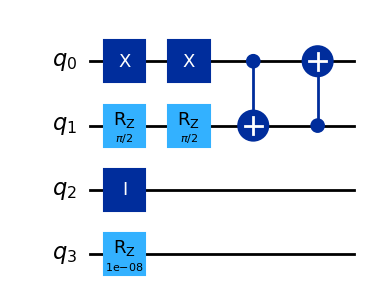

In [14]:
qc = QuantumCircuit(4)
qc.x(0)
qc.x(0)
qc.rz(np.pi/2, 1)
qc.rz(np.pi/2, 1)

qc.cx(0, 1)
qc.cx(1, 0)

qc.id(2)

qc.rz(0.00000001, 3)

qc.draw('mpl')

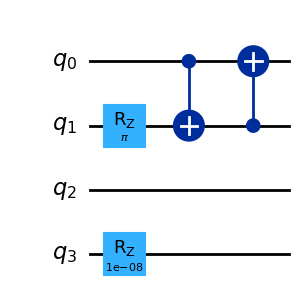

In [15]:
optimized_qc = optimize(qc)
optimized_qc.draw('mpl')

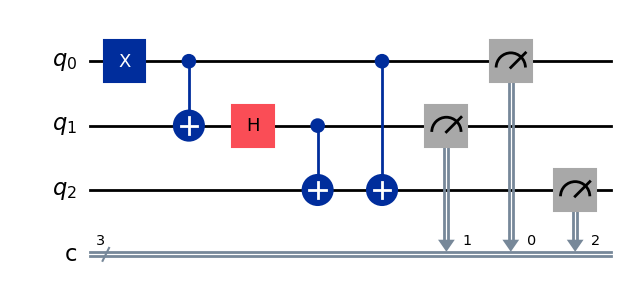

In [3]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

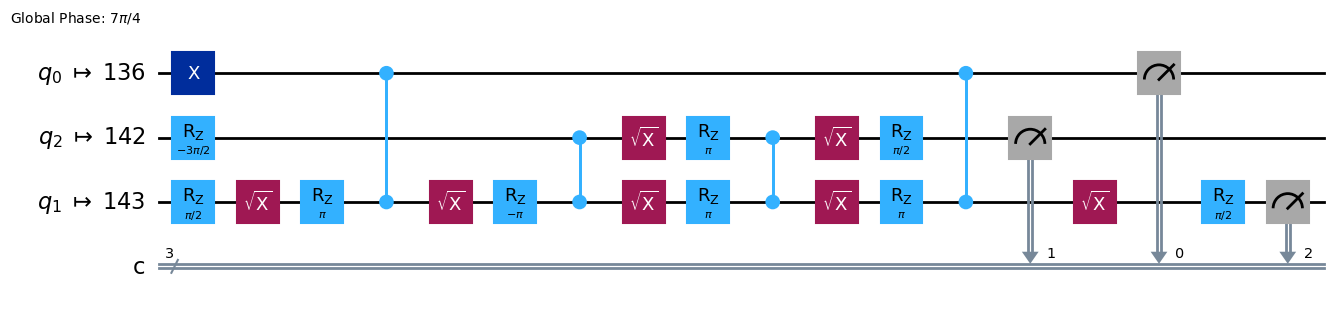

In [11]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)

transpiled_circuit.draw("mpl") 

In [12]:
sampler = Sampler(mode=backend)
job = sampler.run([transpiled_circuit], shots=1024)
counts = job.result()[0].join_data().get_counts()
print("Noisy sim counts:", counts)

Noisy sim counts: {'101': 516, '011': 478, '001': 12, '111': 5, '110': 2, '100': 3, '010': 7, '000': 1}
